1_exploratory_data_analysis includes:

- Loading and preliminary view of the dataset: Review of its structure and initial values.
- Data cleaning: Handling missing values and date conversion.
- Univariate analysis: Distribution of events by channel.
- ivariate analysis: Conversion rate by channel and distribution of survey scores.
- Temporal analysis: Event trends over time.
- Saving processed data: The processed dataset is saved in processed_data.csv.

In [2]:
# Importing Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Setting Visualization Style
sns.set_theme(style="whitegrid")

# Load Dataset
data_path = "simulated_multichannel_data.csv"
data = pd.read_csv(data_path)

# Display First Few Rows
print("Preview of the Dataset:")
display(data.head())


Preview of the Dataset:


,user_id,timestamp,channel,event_type,conversion,survey_score
0,user_716,2025-01-11 01:40:58,social_media,click,0,NaN
1,user_775,2025-01-06 15:11:40,social_media,click,0,NaN
2,user_968,2025-01-09 16:24:57,organic_search,click,0,NaN
3,user_862,2025-01-23 08:11:47,email,conversion,1,5.0
4,user_524,2025-01-09 00:43:19,direct,click,0,NaN


In [3]:

# Basic Information
print("\nDataset Information:")
data.info()


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   user_id       5000 non-null   object 
 1   timestamp     5000 non-null   object 
 2   channel       5000 non-null   object 
 3   event_type    5000 non-null   object 
 4   conversion    5000 non-null   int64  
 5   survey_score  444 non-null    float64
dtypes: float64(1), int64(1), object(4)
memory usage: 234.5+ KB


In [4]:
# Summary Statistics
print("\nSummary Statistics:")
display(data.describe(include='all'))
	


Summary Statistics:


,user_id,timestamp,channel,event_type,conversion,survey_score
count,5000,5000,5000,5000,5000.000000,444.000000
unique,993,4996,5,3,NaN,NaN
top,user_529,2025-01-09 15:15:13,organic_search,click,NaN,NaN
freq,14,2,1047,2502,NaN,NaN
mean,NaN,NaN,NaN,NaN,0.102800,3.033784
std,NaN,NaN,NaN,NaN,0.303728,1.420976
min,NaN,NaN,NaN,NaN,0.000000,1.000000
25%,NaN,NaN,NaN,NaN,0.000000,2.000000
50%,NaN,NaN,NaN,NaN,0.000000,3.000000
75%,NaN,NaN,NaN,NaN,0.000000,4.000000


In [5]:
# Check for Missing Values
print("\nMissing Values:")
missing_values = data.isnull().sum()
display(missing_values[missing_values > 0])


Missing Values:


survey_score    4556
dtype: int64

In [6]:
# Data Preprocessing
data["survey_score"] = data["survey_score"].fillna(data["survey_score"].median())

# Convert timestamp to datetime
print("\nConverting 'timestamp' column to datetime...")
data["timestamp"] = pd.to_datetime(data["timestamp"], errors='coerce')
display(data.head())


Converting 'timestamp' column to datetime...


,user_id,timestamp,channel,event_type,conversion,survey_score
0,user_716,2025-01-11 01:40:58,social_media,click,0,3.0
1,user_775,2025-01-06 15:11:40,social_media,click,0,3.0
2,user_968,2025-01-09 16:24:57,organic_search,click,0,3.0
3,user_862,2025-01-23 08:11:47,email,conversion,1,5.0
4,user_524,2025-01-09 00:43:19,direct,click,0,3.0



Univariate Analysis:


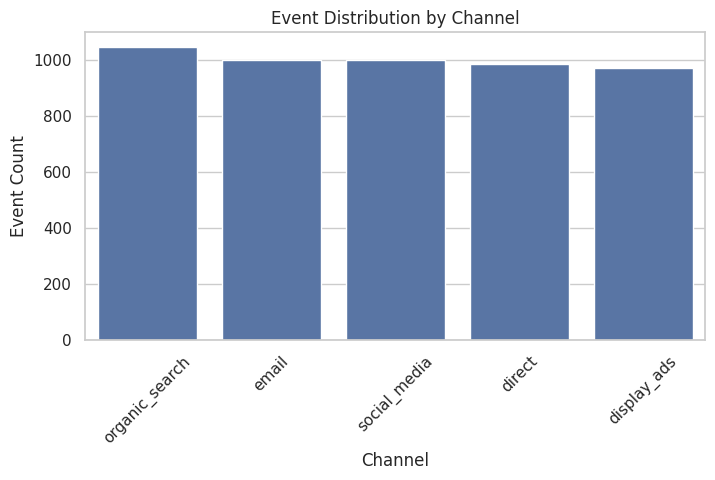

In [7]:
# Univariate Analysis
print("\nUnivariate Analysis:")
## Distribution of Events by Channel
plt.figure(figsize=(8, 4))
sns.countplot(x="channel", data=data, order=data["channel"].value_counts().index)
plt.title("Event Distribution by Channel")
plt.xlabel("Channel")
plt.ylabel("Event Count")
plt.xticks(rotation=45)
plt.show()

In [8]:
## Conversion Rate
conversion_rate = data["conversion"].mean() * 100
print(f"Overall Conversion Rate: {conversion_rate:.2f}%")

Overall Conversion Rate: 10.28%



Bivariate Analysis:


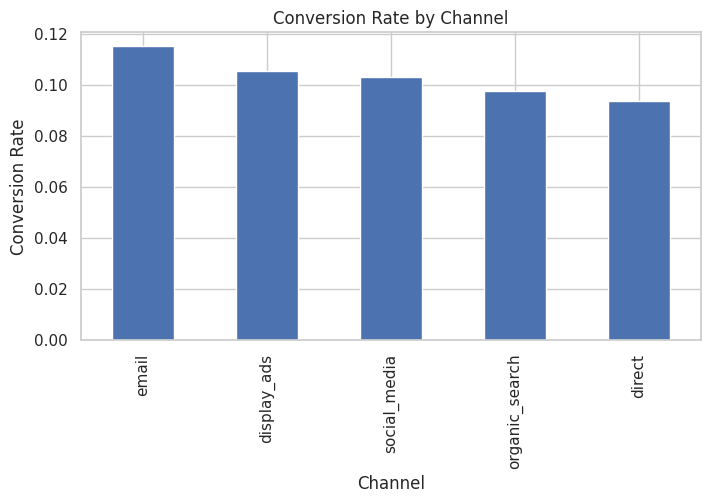

channel
email             0.115000
display_ads       0.105155
social_media      0.103103
organic_search    0.097421
direct            0.093496
Name: conversion, dtype: float64

In [9]:
# Bivariate Analysis
print("\nBivariate Analysis:")
## Conversion Rate by Channel
conversion_by_channel = data.groupby("channel")["conversion"].mean().sort_values(ascending=False)
#Graphic
plt.figure(figsize=(8, 4))
conversion_by_channel.plot(kind="bar")
plt.title("Conversion Rate by Channel")
plt.ylabel("Conversion Rate")
plt.xlabel("Channel")
plt.show()
conversion_by_channel.head()

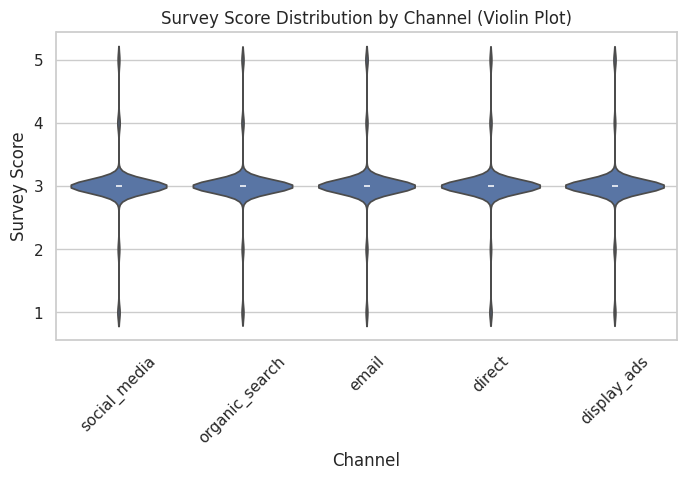

In [14]:
# Survey Score Distribution by Channel
plt.figure(figsize=(8, 4))
sns.violinplot(x="channel", y="survey_score", data=data, inner="box")
plt.title("Survey Score Distribution by Channel (Violin Plot)")
plt.xlabel("Channel")
plt.ylabel("Survey Score")
plt.xticks(rotation=45)
plt.show()


Time Series Analysis:


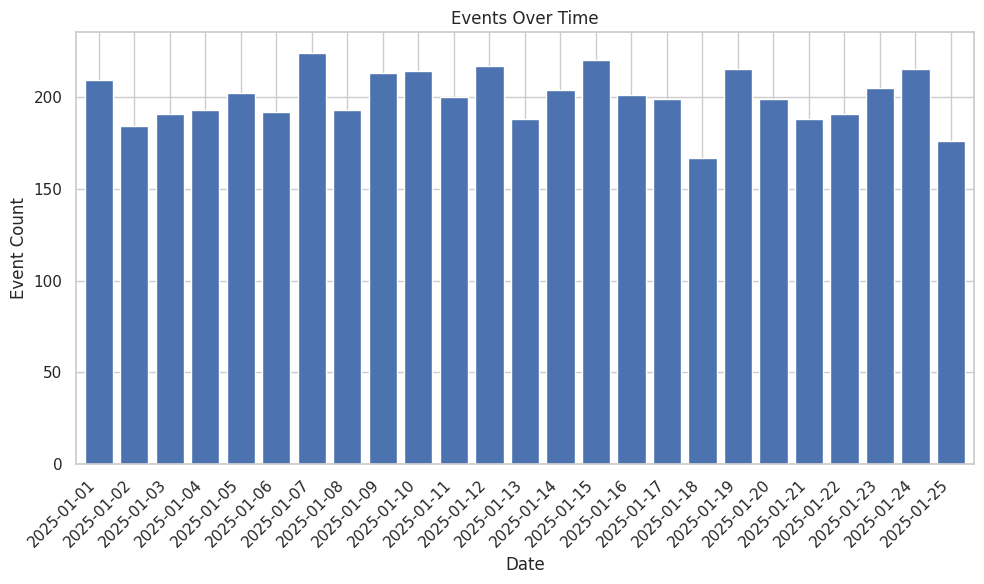

In [16]:
# Time Series Analysis
print("\nTime Series Analysis:")
## Grouping events by date
data["date"] = data["timestamp"].dt.date  # Extract the date (without time)
event_counts = data["date"].value_counts().sort_index()  # Count events per date, sorted chronologically

## Plotting the bar chart
plt.figure(figsize=(10, 6))
event_counts.plot(kind="bar", width=0.8)  # Use bar plot for events
plt.title("Events Over Time")
plt.xlabel("Date")
plt.ylabel("Event Count")
plt.xticks(rotation=45, ha="right")  # Rotate x-axis labels for better readability
plt.tight_layout()  # Adjust layout to fit everything
plt.show()

In [12]:
# Save Processed Dataset
processed_path = "processed_data.csv"
data.to_csv(processed_path, index=False)
print(f"\nProcessed data saved to {processed_path}")


Processed data saved to processed_data.csv
